Using device: cuda:0


100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


CIFAR-10 cargado. Train: 45000, Val: 5000

Analyzing ResNet Depth Scaling
ResNet-18: 11,173,962 params, 1.82s train sim, 3.69ms inference
ResNet-34: 21,289,802 params, 0.19s train sim, 3.74ms inference
ResNet-50: 23,528,522 params, 0.29s train sim, 5.25ms inference
ResNet-101: 42,520,650 params, 0.39s train sim, 10.51ms inference

--- COMENZANDO ENTRENAMIENTO REAL DE LOS MODELOS ---

--- Entrenando ResNet por 10 epochs ---
Epoch 1/10 | Train Loss: 1.7489 | Val Acc: 44.70%
Epoch 2/10 | Train Loss: 1.2244 | Val Acc: 61.82%
Epoch 3/10 | Train Loss: 0.9206 | Val Acc: 62.30%
Epoch 4/10 | Train Loss: 0.7275 | Val Acc: 70.34%
Epoch 5/10 | Train Loss: 0.5978 | Val Acc: 71.94%
Epoch 6/10 | Train Loss: 0.3332 | Val Acc: 82.98%
Epoch 7/10 | Train Loss: 0.2444 | Val Acc: 83.56%
Epoch 8/10 | Train Loss: 0.1781 | Val Acc: 84.22%
Epoch 9/10 | Train Loss: 0.1631 | Val Acc: 84.22%
Epoch 10/10 | Train Loss: 0.1554 | Val Acc: 84.12%

--- Entrenando ResNet por 10 epochs ---
Epoch 1/10 | Train Loss: 2.3031

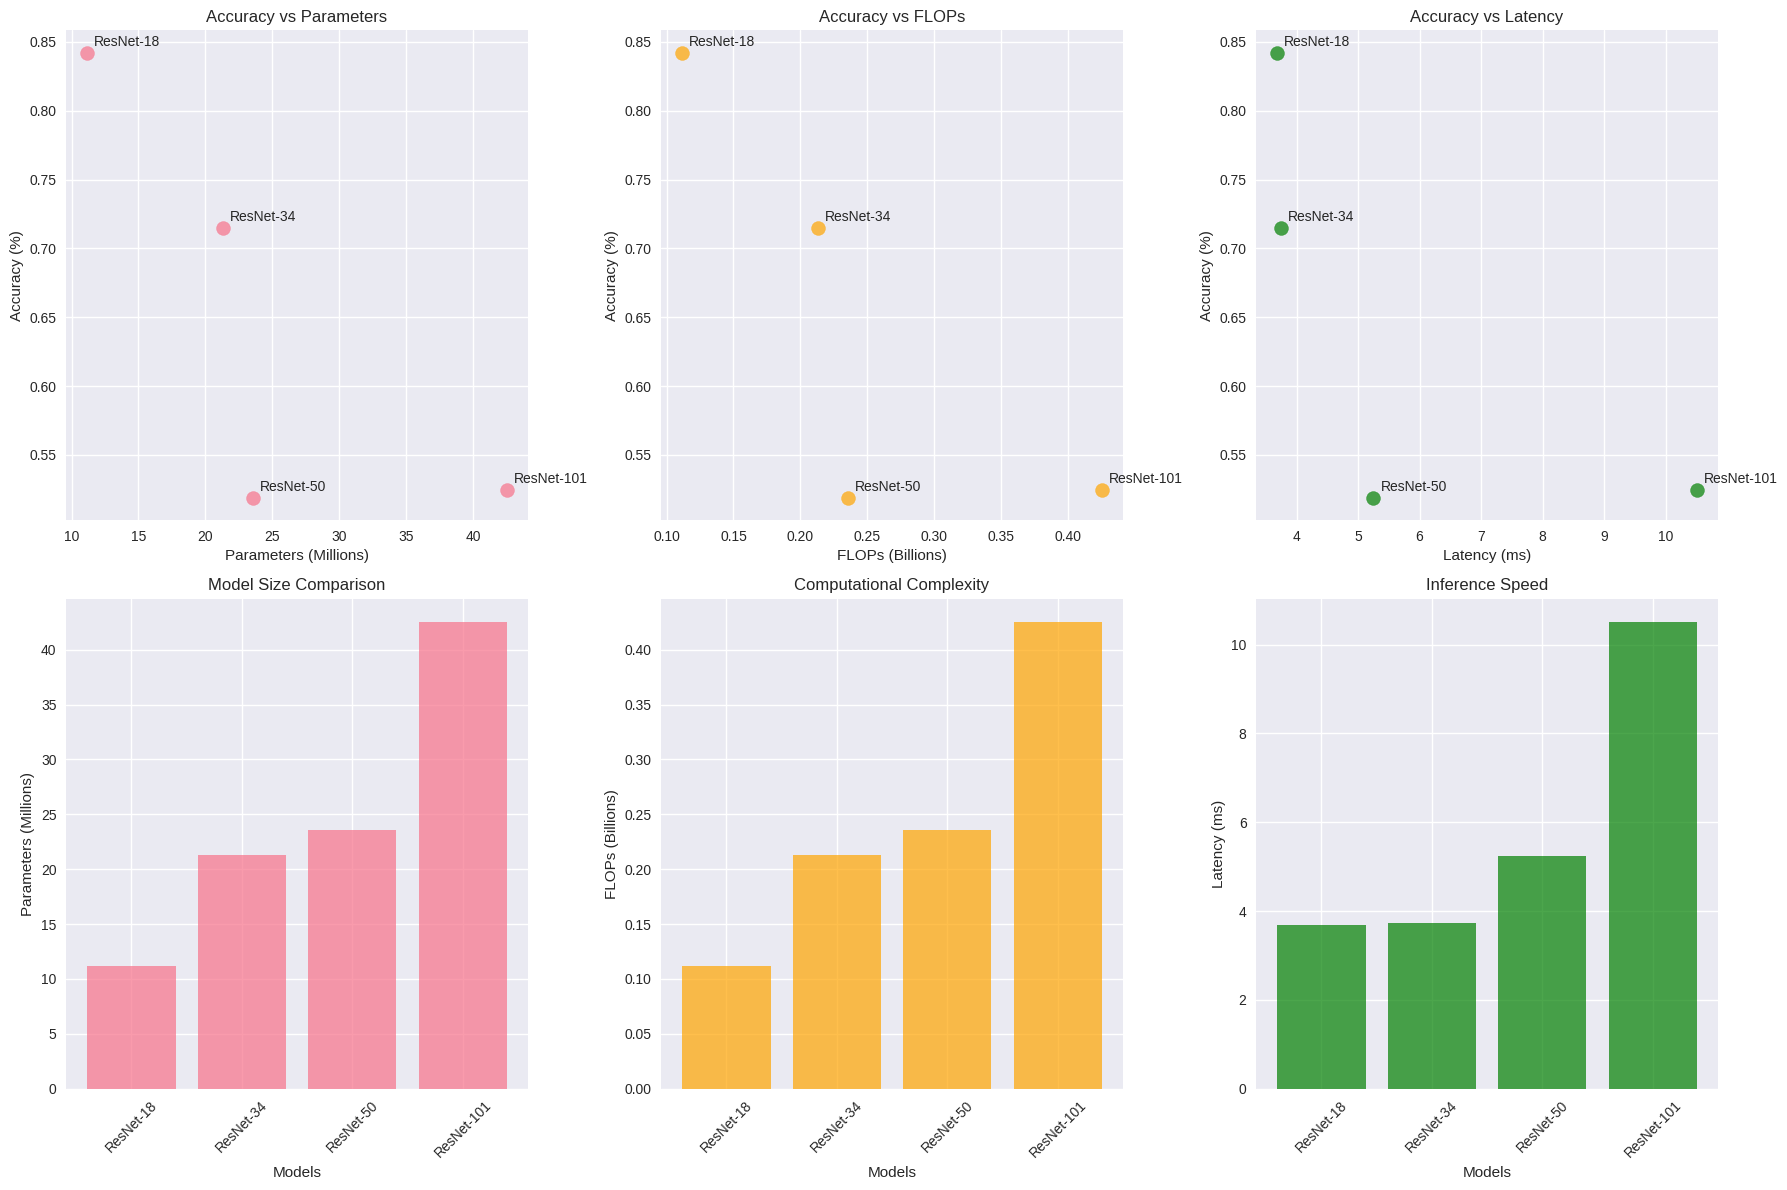

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import Dict, Any, Optional
from lab03_student import *
from utils import TrainingVisualizer

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#Data Loaders
def get_cifar10_loaders(batch_size: int = 128, val_ratio: float = 0.1, num_workers: int = 2) -> Dict[str, DataLoader]:
    """Descarga CIFAR-10 y crea DataLoaders."""

    transform = transforms.Compose([
        transforms.ToTensor(),
        # Normalización estándar de CIFAR-10
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    train_val_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

    total_train_size = len(train_val_set)
    val_size = int(val_ratio * total_train_size)
    train_size = total_train_size - val_size

    train_subset, val_subset = torch.utils.data.random_split(
        train_val_set,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    print(f"CIFAR-10 cargado. Train: {len(train_subset)}, Val: {len(val_subset)}")
    return {'train': train_loader, 'val': val_loader, 'test': test_loader}


def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, epochs: int, lr: float = 0.1) -> Dict[str, Any]:
    """Entrena y evalúa el modelo, devolviendo la precisión final."""

    criterion = nn.CrossEntropyLoss()
    # Usar SGD con Momentum (el estándar para ResNet)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

    # CORRECCIÓN AQUÍ: Usar torch.optim.lr_scheduler para MultiStepLR
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[int(epochs * 0.5), int(epochs * 0.75)], gamma=0.1)

    model.to(device)
    best_accuracy = 0.0
    history = {'train_loss': [], 'val_accuracy': []}

    print(f"\n--- Entrenando {model.__class__.__name__} por {epochs} epochs ---")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step() # Ajustar el Learning Rate

        # Evaluación de la época
        val_acc, val_loss = evaluate_model(model, val_loader, criterion)
        history['train_loss'].append(running_loss / len(train_loader))
        history['val_accuracy'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {history['train_loss'][-1]:.4f} | Val Acc: {val_acc:.2f}%")

        if val_acc > best_accuracy:
            best_accuracy = val_acc

    # Calcular y devolver memoria máxima (solo si se usa CUDA)
    memory_usage_mb = torch.cuda.max_memory_allocated() / (1024 * 1024) if device.type == 'cuda' else 0

    return {
        'final_accuracy': best_accuracy / 100.0, # Devuelve en ratio (ej: 0.901)
        'memory_usage_mb': memory_usage_mb,
        'history': history
    }

def evaluate_model(model: nn.Module, data_loader: DataLoader, criterion: nn.Module) -> tuple:
    """Calcula la precisión y la pérdida en el conjunto de datos."""
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = total_loss / total
    return accuracy, avg_loss


def analyze_resnet_scaling() -> Dict[str, Dict[str, Any]]:
    """Analiza cómo el rendimiento de ResNet escala con la profundidad/costo."""
    print("\nAnalyzing ResNet Depth Scaling")
    print("=" * 40)

    models = {
        'ResNet-18': resnet18(num_classes=10),
        'ResNet-34': resnet34(num_classes=10),
        'ResNet-50': resnet50(num_classes=10),
        'ResNet-101': resnet101(num_classes=10)
    }

    results = {}

    BATCH_SIZE = 4
    test_input = torch.randn(BATCH_SIZE, 3, 32, 32)
    target_labels = torch.zeros(BATCH_SIZE, dtype=torch.long) # Targets for the dummy loss

    for name, model in models.items():
        if model is not None:
            model.to(device)
            current_input = test_input.to(device)
            current_target = target_labels.to(device)

            # 1. Count parameters
            params = sum(p.numel() for p in model.parameters())

            # 2. Measure TRAIN time (simulación de una pasada completa)
            optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
            criterion = nn.CrossEntropyLoss()
            model.train()

            start_time_train = time.time()
            for _ in range(10):
                optimizer.zero_grad()
                outputs = model(current_input)
                loss = criterion(outputs, current_target)
                loss.backward()
                optimizer.step()
            train_time = time.time() - start_time_train

            # 3. Measure INFERENCE time (Latencia)
            model.eval()
            start_time_inf = time.time()
            with torch.no_grad():
                for _ in range(100):
                    _ = model(current_input)
            avg_time = (time.time() - start_time_inf) / 100 * 1000  # ms

            # 4. Uso de Memoria Máxima (solo GPU)
            max_memory_mb = 0
            if device.type == 'cuda':
                max_memory_mb = torch.cuda.max_memory_allocated() / (1024 * 1024)

            # 5. FLOPs (Placeholder, usar un estimador real si es posible, sino simular con Parámetros)
            # Simulación: FLOPs es aproximadamente 10x los parámetros para ResNet en CIFAR
            flops_sim = params * 10

            results[name] = {
                'parameters': params,
                'train_time_sim': train_time,
                'inference_time': avg_time,
                'flops': flops_sim,
                'memory': max_memory_mb
            }

            print(f"{name}: {params:,} params, {train_time:.2f}s train sim, {avg_time:.2f}ms inference")

    return results

def run_full_analysis_and_plot(epochs: int = 10, batch_size: int = 128, plot_model: Optional[Any] = None) -> Dict[str, Any]:

    # 1. Cargar DataLoaders
    data_loaders = get_cifar10_loaders(batch_size=batch_size)

    # 2. Obtener las métricas de Costo/Escalado (Parámetros, Latencia, FLOPs)
    scaling_results = analyze_resnet_scaling()

    # 3. Instanciar modelos para el entrenamiento real
    models_to_train = {
        'ResNet-18': resnet18(num_classes=10),
        'ResNet-34': resnet34(num_classes=10),
        'ResNet-50': resnet50(num_classes=10),
        'ResNet-101': resnet101(num_classes=10)
    }

    full_training_history = {}

    print("\n--- COMENZANDO ENTRENAMIENTO REAL DE LOS MODELOS ---")

    # NOTA: El entrenamiento de ResNet requiere muchas epochs (ej. 100-200) para
    # alcanzar la precisión máxima. Usamos 10 epochs aquí para un test rápido.
    for name, model in models_to_train.items():
        # Llamar a la función de entrenamiento
        results = train_model(model, data_loaders['train'], data_loaders['val'], epochs=epochs)
        full_training_history[name] = results

    # 4. CONSOLIDACIÓN FINAL DE DATOS
    final_comparison_data = {}

    for name in models_to_train.keys():
        if name in scaling_results and name in full_training_history:
            cost_metrics = scaling_results[name]
            train_metrics = full_training_history[name]

            final_comparison_data[name] = {
                'accuracy': train_metrics['final_accuracy'],
                'parameters': cost_metrics['parameters'],
                'flops': cost_metrics['flops'],
                'latency': cost_metrics['inference_time'],
                'memory': train_metrics['memory_usage_mb']
            }

    # 5. GENERAR EL GRÁFICO (Precisión vs. Profundidad/Costo)
    plot_model(final_comparison_data, save_path='resnet_scaling_comparison_final.png')

    return final_comparison_data

# 5. EJECUCIÓN FINAL
if __name__ == '__main__':

    FINAL_EPOCHS = 10
    FINAL_BATCH_SIZE = 128
    plot = TrainingVisualizer.plot_model_comparison
    run_full_analysis_and_plot(FINAL_EPOCHS, FINAL_BATCH_SIZE,plot_model=plot)